# L03 Cortical Column Voting Simulation
This includes implementation & visualizations

**Name:** Hillary Bruton  
**Course:** ITAI 4374: Neuroscience as a Model for AI  
**Platform:** Python / Google Colab

## Lab Objective
This lab explores how biological and artificial neurons process information. I implemented a simplified biological neuron model, an artificial neuron with multiple activation functions, and small neural networks to compare information integration across architectures.

In [24]:
import numpy as np
import matplotlib.pyplot as plt

## Part 1: Biological Neural Response

### Understanding Aciton Potentials
Neurons use electrical signals, called action potentials, to transmit information (McManus, ITAI 4374). Course materials (McManus, ITAI 4374) explain:


*   Resting membrane potential: The neuron's stable voltage when it's not actively signaling
*   Threshold potential: The voltage that msut be reached to trigger an action potential.
* Depolarization and repolarization: The rapid changes in membrane potential during an action potential
* Refractory period: The brief period after an action potential when the neuron is less likely to fire again.
* All-or-none principle: The idea that an action potential either happens completely or not at all.

### Simulating a Biological Neuron



In [25]:
from ast import Continue
class BiologicalNeuron: #HCB: this creates a blueprint for a neuron.
    """Simulates basic biological neuron characteristics"""
    def __init__(self): # HCB: These variables represent biological neuron properties.
        self.resting_potential = -70  # mV HCB: a real neuron at rest sits around -70millivolts
        self.threshold = -55  # mV HCB: "trigger point"
        self.peak_potential = 40      # mV #added by Hillary. The action potential spike
        self.reset_potential = -75    # mV #added by Hillary Neurons dip below resting level before recovering to prevent immediate refiring (ChatGPT)
        self.refractory_steps = 5     # simple refractory period #added by Hillary This simulates the brief time where neuron cannot fire again.

    def simulate_response(self, input_current, time_steps=100): #added time constraints
        """Simulates neuron response to input current over time"""
        # Initialize membrane potential to resting potential
        membrane_potential = self.resting_potential
        # Simulate the response over time
        membrane_potentials = [] # Store membrane potential values
        refractory_counter = 0

        for t in range(time_steps):
            # Update membrane potential based on input current (simplified model)
            if refractory_counter > 0:
              membrane_potential = self.reset_potential
              refractory_counter -= 1

            else:
              # integrate input current
              membrane_potential += input_current

              # Check if threshold is reached
              if membrane_potential >= self.threshold:
                # Generate an action potential (simplified representation)

                  membrane_potential = self.peak_potential# Peak potential
                  membrane_potentials.append(membrane_potential)
                  membrane_potential = self.reset_potential
                  refractory_counter = self.refractory_steps
                  continue

            # Simulate decay of membrane potential (simplified model)
            membrane_potential -= 0.2  * (membrane_potential - self.resting_potential) # Adjust decay rate as needed

            membrane_potentials.append(membrane_potential)

        return membrane_potentials

    def plot_response(self, input_current, time_steps=100):
        membrane_potentials = self.simulate_response(input_current, time_steps)
        plt.figure(figsize=(10,4))
        plt.plot(membrane_potentials, linewidth=2)
        plt.axhline(self.threshold, color='r', linestyle='--', label='Threshold')
        plt.axhline(self.resting_potential, color='g', linestyle=":", label='Resting Potential')
        plt.xlabel("Time Step")
        plt.ylabel("Membrane Potential (mV)")
        plt.title(f"Biological Neuron Response (Input Current = {input_current})")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

        # Plot the membrane potential over time
        plt.plot(membrane_potentials)
        plt.xlabel("Time")
        plt.ylabel("Membrane Potential (mV)")
        plt.title("Biological Neuron Response")
        plt.show()

# Example usage
neuron = BiologicalNeuron()
neuron.simulate_response(1)  # Example input current

[-69.2,
 -68.56,
 -68.048,
 -67.6384,
 -67.31072,
 -67.048576,
 -66.83886079999999,
 -66.67108864,
 -66.536870912,
 -66.4294967296,
 -66.34359738368,
 -66.274877906944,
 -66.2199023255552,
 -66.17592186044416,
 -66.14073748835533,
 -66.11258999068426,
 -66.09007199254741,
 -66.07205759403793,
 -66.05764607523034,
 -66.04611686018427,
 -66.03689348814741,
 -66.02951479051794,
 -66.02361183241435,
 -66.01888946593148,
 -66.01511157274518,
 -66.01208925819614,
 -66.00967140655692,
 -66.00773712524554,
 -66.00618970019643,
 -66.00495176015714,
 -66.00396140812572,
 -66.00316912650058,
 -66.00253530120047,
 -66.00202824096037,
 -66.0016225927683,
 -66.00129807421465,
 -66.00103845937171,
 -66.00083076749738,
 -66.0006646139979,
 -66.00053169119832,
 -66.00042535295866,
 -66.00034028236692,
 -66.00027222589354,
 -66.00021778071483,
 -66.00017422457186,
 -66.0001393796575,
 -66.000111503726,
 -66.0000892029808,
 -66.00007136238465,
 -66.00005708990771,
 -66.00004567192617,
 -66.00003653754094

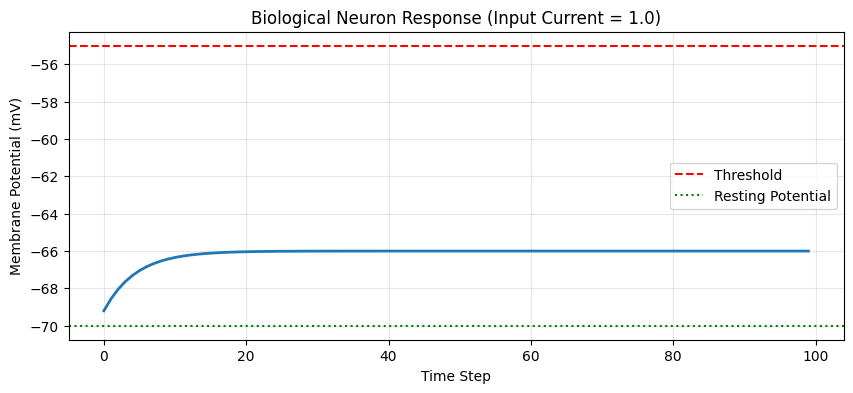

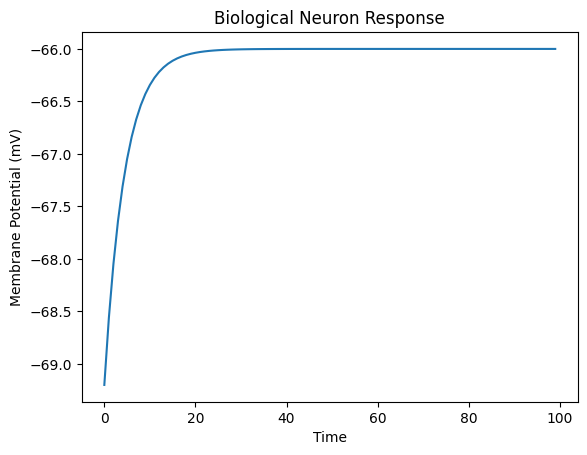

In [26]:
# Test biological neuron with one current
bio_neuron = BiologicalNeuron()
bio_neuron.plot_response(1.0)

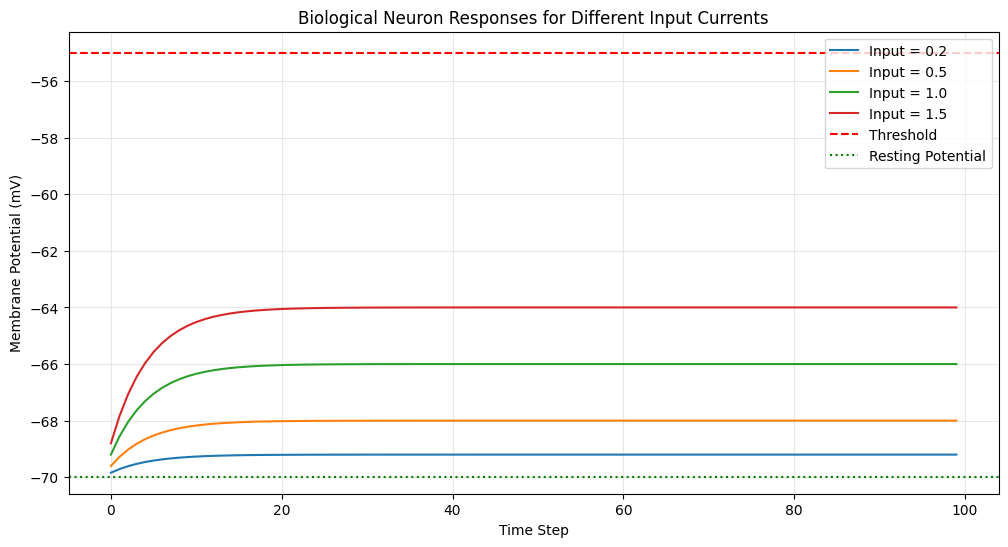

In [27]:
#Compare different input currents
input_currents = [0.2, 0.5, 1.0, 1.5]

plt.figure(figsize=(12, 6))
for current in input_currents:
    response = bio_neuron.simulate_response(current, time_steps=100)
    plt.plot(response, label=f"Input = {current}")

plt.axhline(bio_neuron.threshold, color='r', linestyle='--', label='Threshold')
plt.axhline(bio_neuron.resting_potential, color='g', linestyle=':', label='Resting Potential')
plt.xlabel("Time Step")
plt.ylabel("Membrane Potential (mV)")
plt.title("Biological Neuron Responses for Different Input Currents")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Analyze the Response & Observations

In real neuroscience, neurons sit at a resting voltage of ~ -70mV, receive input signals, if enough signal accumulates, they fire a spike, and then they reset and rest breifly (refractory period) before firing again. The Cell 03 class created models those behaviors.

* How does the input current affect the generation of action potentials?
* What happens when the input current is below the threshold?
* How does the neuron's repsonse change with varying input strengths?

1. Small current may never reach threshold
2. Medium current may reach threshold occasionally
3. Larger current produces more frequent spikes
4. The refractory period prevents continuous firing
5. This demonstrates the all-or-none principle

## Part 2: Artificial Neuron Implementation

### Building an Artificial Neuron
These are the building blocks of artificial neuron networks

### Artificial Neuron Class

In [28]:
class ArtificialNeuron:
    """Implements artificial neuron for comparison"""

    def __init__(self, num_inputs):
        self.weights = np.random.randn(num_inputs)
        self.bias = 0.0

    def activate(self, inputs, activation="sigmoid"):
        """Implements artificial neuron activation"""
        weighted_sum = np.dot(self.weights, inputs) + self.bias

        if activation == "sigmoid":
            output = 1 / (1 + np.exp(-weighted_sum))
        elif activation == "relu":
            output = max(0, weighted_sum)
        elif activation == "tanh":
            output = np.tanh(weighted_sum)
        else:
            raise ValueError("Unsupported activation function")

        return output, weighted_sum

### Test the artificial neuron

In [29]:
np.random.seed(42)
art_neuron = ArtificialNeuron(3)

inputs = np.array([0.5, 0.2, 0.8])

for fn in ["sigmoid", "relu", "tanh"]:
    output, weighted_sum = art_neuron.activate(inputs, activation=fn)
    print(f"{fn.upper()} -> weighted sum: {weighted_sum:.4f}, output: {output:.4f}")

SIGMOID -> weighted sum: 0.7389, output: 0.6767
RELU -> weighted sum: 0.7389, output: 0.7389
TANH -> weighted sum: 0.7389, output: 0.6285


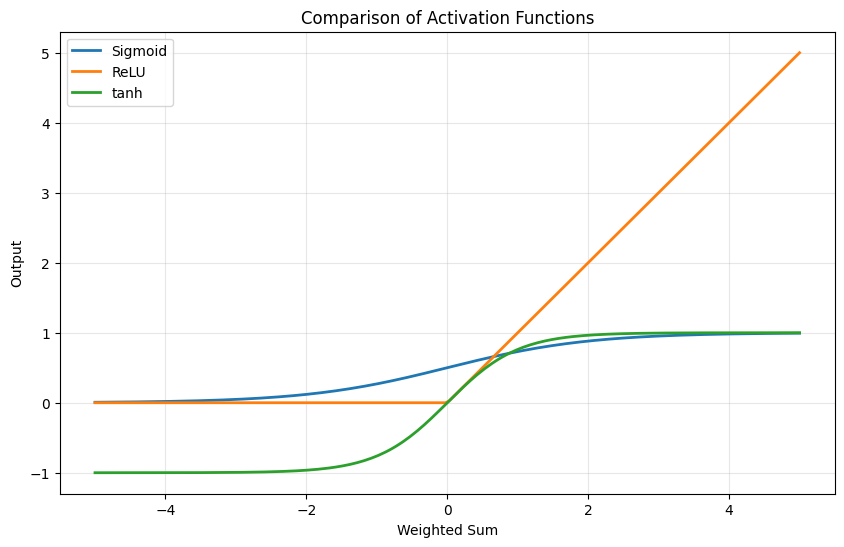

In [30]:
# Activation funciton comparison graphs
x = np.linspace(-5, 5, 200)
sigmoid = 1 / (1 + np.exp(-x))
relu = np.maximum(0, x)
tanh = np.tanh(x)

plt.figure(figsize=(10, 6))
plt.plot(x, sigmoid, label="Sigmoid", linewidth=2)
plt.plot(x, relu, label="ReLU", linewidth=2)
plt.plot(x, tanh, label="tanh", linewidth=2)
plt.xlabel("Weighted Sum")
plt.ylabel("Output")
plt.title("Comparison of Activation Functions")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Comparing input/output behavior of artificial neuron

In [31]:
#This creates a list of input vectors. Each vector represents signals entering the neuron. Similar to synapses sending signals to the neuron.
test_inputs = [
    np.array([0.1, 0.1, 0.1]),
    np.array([0.5, 0.2, 0.8]),
    np.array([1.0, 1.0, 1.0]),
    np.array([-0.5, 0.3, 0.9])
]

for inp in test_inputs:
    print(f"\nInputs: {inp}")
    for fn in ["sigmoid", "relu", "tanh"]:
        output, weighted_sum = art_neuron.activate(inp, activation=fn)
        print(f"  {fn.upper()} -> weighted sum: {weighted_sum:.4f}, output: {output:.4f}")


Inputs: [0.1 0.1 0.1]
  SIGMOID -> weighted sum: 0.1006, output: 0.5251
  RELU -> weighted sum: 0.1006, output: 0.1006
  TANH -> weighted sum: 0.1006, output: 0.1003

Inputs: [0.5 0.2 0.8]
  SIGMOID -> weighted sum: 0.7389, output: 0.6767
  RELU -> weighted sum: 0.7389, output: 0.7389
  TANH -> weighted sum: 0.7389, output: 0.6285

Inputs: [1. 1. 1.]
  SIGMOID -> weighted sum: 1.0061, output: 0.7323
  RELU -> weighted sum: 1.0061, output: 1.0061
  TANH -> weighted sum: 1.0061, output: 0.7642

Inputs: [-0.5  0.3  0.9]
  SIGMOID -> weighted sum: 0.2931, output: 0.5728
  RELU -> weighted sum: 0.2931, output: 0.2931
  TANH -> weighted sum: 0.2931, output: 0.2850


### Analyze the Response & Observations

The lab requires that we observe how the neuron behaves under different signal conditions. Weak signals, mixed moderate signals, strong activation, and inclusion of an inhibitory signal. The last trial is important because it demonstrates how artificial neurons can receive negative inputs, similar to inhibitory synapses in biology.

* How do the input-output relationships differ between the two models?
* What are the key distinctions in information processing between biological and artificial neurons?
* How do the concepts of threshold and activation function relate to each other?

The weighted sum stayed the same, but the activation outputs differ. Same signal, but received a different neuron behavior. Cell 9 showed how different activations changed the output behavior.

While the weighted sum remains constant across activation functions, the output varies significantly depending on the function used. Sigmoid compresses values between 0 and 1, tanh outputs values between -1 and 1, and ReLU passes positive values unchanged while suppressing negative values. This demonstrates how activation functions influence how artificial neurons represent information and why choosing the correct function is important in neural network design.

## Part 3: Information Integration Study

### Creating Simple Networks
Connect the neurons in differnet configurations feedforward, recurrent.
This is a simplified feedforward biological-style network.

In [36]:
#Simple biological network
class BiologicalNetwork:
    """Simple feedforward biological neuron network"""

    def __init__(self, num_neurons):
        self.neurons = [BiologicalNeuron() for _ in range(num_neurons)]

    def simulate_network(self, input_currents, time_steps=50):
        all_responses = []
        for neuron, current in zip(self.neurons, input_currents):
            response = neuron.simulate_response(current, time_steps=time_steps)
            all_responses.append(response)
        return np.array(all_responses)

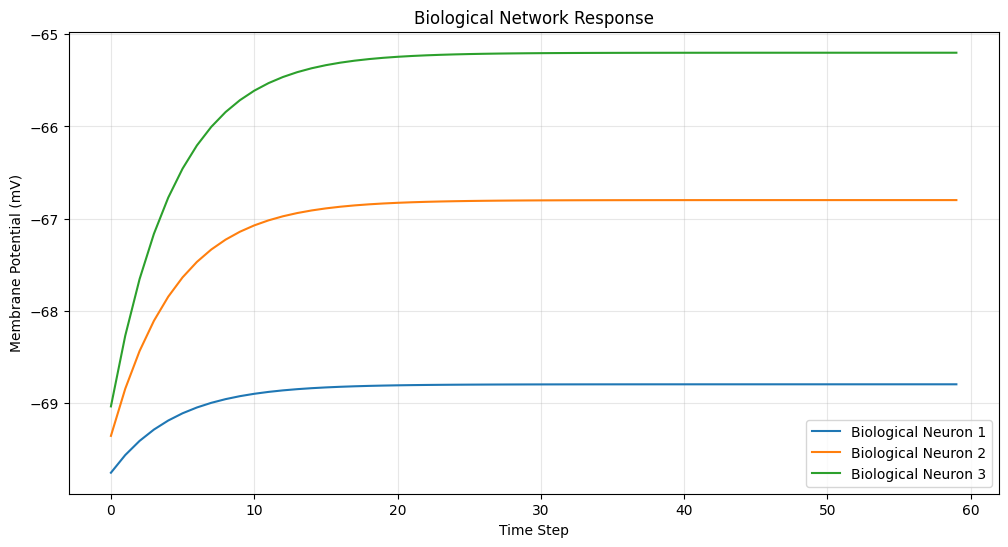

In [37]:
# Testing the biological network
bio_net = BiologicalNetwork(3)
bio_net_response = bio_net.simulate_network([0.3, 0.8, 1.2], time_steps=60)

plt.figure(figsize=(12, 6))
for i in range(bio_net_response.shape[0]):
    plt.plot(bio_net_response[i], label=f"Biological Neuron {i+1}")
plt.xlabel("Time Step")
plt.ylabel("Membrane Potential (mV)")
plt.title("Biological Network Response")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [34]:
# Simple artificial feedforward network usign one hidden layer

class ArtificialNetwork:
    """Simple artificial neural network with one hidden layer"""

    def __init__(self, input_size, hidden_size, output_size):
        self.W1 = np.random.randn(hidden_size, input_size)
        self.b1 = np.zeros(hidden_size)
        self.W2 = np.random.randn(output_size, hidden_size)
        self.b2 = np.zeros(output_size)

    def forward(self, inputs, activation="sigmoid"):
        z1 = np.dot(self.W1, inputs) + self.b1

        if activation == "sigmoid":
            a1 = 1 / (1 + np.exp(-z1))
        elif activation == "relu":
            a1 = np.maximum(0, z1)
        elif activation == "tanh":
            a1 = np.tanh(z1)
        else:
            raise ValueError("Unsupported activation")

        z2 = np.dot(self.W2, a1) + self.b2

        if activation == "sigmoid":
            output = 1 / (1 + np.exp(-z2))
        elif activation == "relu":
            output = np.maximum(0, z2)
        elif activation == "tanh":
            output = np.tanh(z2)

        return a1, output

In [35]:
#Testing artificial network with different inputs
np.random.seed(42)
art_net = ArtificialNetwork(input_size=3, hidden_size=4, output_size=2)

input_patterns = [
    np.array([0.1, 0.1, 0.1]),
    np.array([0.9, 0.2, 0.3]),
    np.array([0.2, 0.8, 0.6]),
    np.array([1.0, 1.0, 1.0])
]

for i, pattern in enumerate(input_patterns):
    hidden, output = art_net.forward(pattern, activation="sigmoid")
    print(f"\nPattern {i+1}: {pattern}")
    print(f"Hidden layer: {hidden}")
    print(f"Output: {output}")


Pattern 1: [0.1 0.1 0.1]
Hidden layer: [0.52513226 0.52634407 0.54679201 0.49033652]
Output: [0.10920739 0.17429728]

Pattern 2: [0.9 0.2 0.3]
Hidden layer: [0.64878355 0.77793194 0.80751387 0.56362854]
Output: [0.04559731 0.12543907]

Pattern 3: [0.2 0.8 0.6]
Hidden layer: [0.59323247 0.49420053 0.65658346 0.36780151]
Output: [0.10514071 0.1734768 ]

Pattern 4: [1. 1. 1.]
Hidden layer: [0.73226375 0.74168398 0.86728609 0.40453908]
Output: [0.04901678 0.13383868]


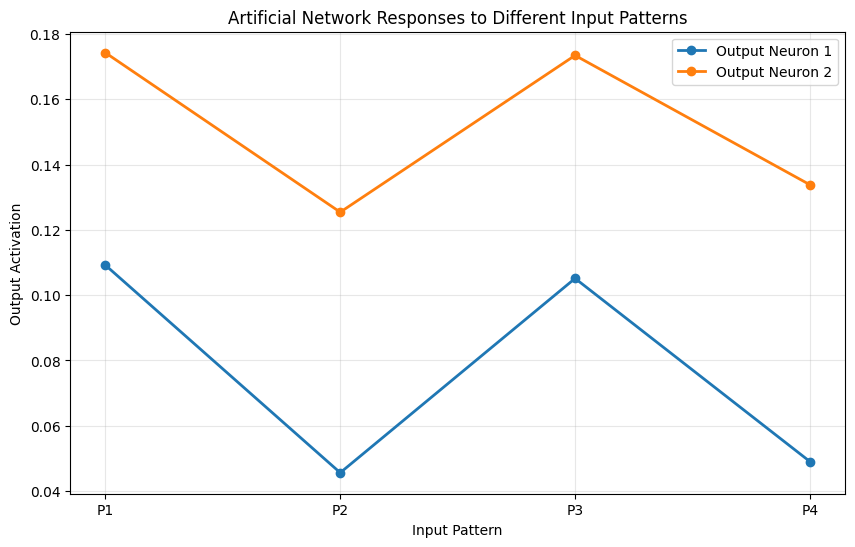

In [38]:
#network response
outputs = []

for pattern in input_patterns:
    _, output = art_net.forward(pattern, activation="sigmoid")
    outputs.append(output)

outputs = np.array(outputs)

plt.figure(figsize=(10, 6))
for i in range(outputs.shape[1]):
    plt.plot(outputs[:, i], marker='o', linewidth=2, label=f"Output Neuron {i+1}")

plt.xticks(range(len(input_patterns)), [f"P{i+1}" for i in range(len(input_patterns))])
plt.xlabel("Input Pattern")
plt.ylabel("Output Activation")
plt.title("Artificial Network Responses to Different Input Patterns")
plt.legend()
plt.grid(alpha=0.3)
plt.show()